Clean test performance:
Accuracy: 0.7920
AUC: 0.8554

PGD robustness audit results:
   epsilon  accuracy     auc  prediction_flip_rate
0     0.00    0.7920  0.8554                0.0000
1     0.05    0.7427  0.8112                0.0493
2     0.10    0.6987  0.7578                0.0933
3     0.15    0.6493  0.6958                0.1427
4     0.20    0.5973  0.6273                0.1947
5     0.25    0.5347  0.5528                0.2573


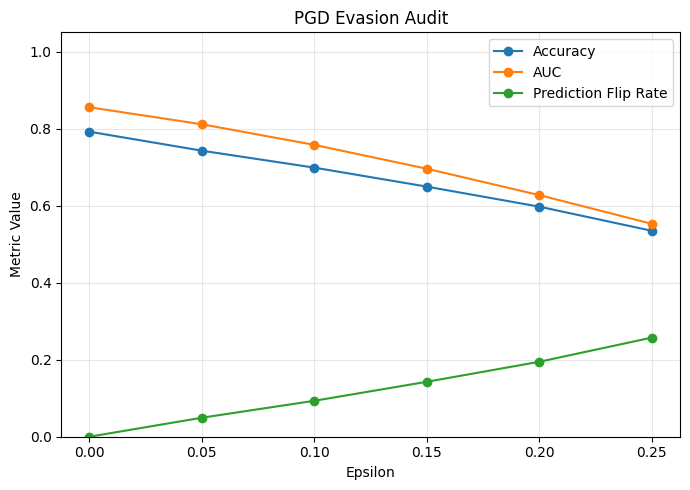

In [1]:
# Python PGD Evasion Audit Sample
# Standalone demo for robustness testing under adversarial perturbations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score

RANDOM_STATE = 42


def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


def pgd_attack_logreg(X, y, w, b, epsilon=0.20, alpha=0.02, steps=20):
    """
    Simple PGD attack for logistic regression under L-infinity constraint.
    Assumes binary labels y in {0,1}.
    """
    X_adv = X.copy().astype(float)
    X_orig = X.copy().astype(float)

    y_signed = np.where(y == 1, 1.0, -1.0)

    for _ in range(steps):
        margins = y_signed * (X_adv @ w + b)
        probs = sigmoid(-margins)
        grad = -(probs * y_signed)[:, None] * w[None, :]

        X_adv = X_adv + alpha * np.sign(grad)

        perturbation = np.clip(X_adv - X_orig, -epsilon, epsilon)
        X_adv = X_orig + perturbation

    return X_adv


# ------------------------------------------------------------
# 1) Create demo dataset
# ------------------------------------------------------------
X, y = make_classification(
    n_samples=2500,
    n_features=12,
    n_informative=8,
    n_redundant=2,
    class_sep=1.1,
    flip_y=0.02,
    random_state=RANDOM_STATE
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# ------------------------------------------------------------
# 2) Standardize features
# ------------------------------------------------------------
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ------------------------------------------------------------
# 3) Train baseline logistic regression model
# ------------------------------------------------------------
model = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
model.fit(X_train_s, y_train)

clean_probs = model.predict_proba(X_test_s)[:, 1]
clean_preds = (clean_probs >= 0.5).astype(int)

clean_accuracy = accuracy_score(y_test, clean_preds)
clean_auc = roc_auc_score(y_test, clean_probs)

print("Clean test performance:")
print(f"Accuracy: {clean_accuracy:.4f}")
print(f"AUC: {clean_auc:.4f}")

# ------------------------------------------------------------
# 4) Run PGD attacks across multiple epsilon levels
# ------------------------------------------------------------
w = model.coef_.ravel()
b = model.intercept_[0]

epsilons = [0.00, 0.05, 0.10, 0.15, 0.20, 0.25]
results = []

for eps in epsilons:
    if eps == 0:
        X_adv = X_test_s.copy()
    else:
        X_adv = pgd_attack_logreg(
            X=X_test_s,
            y=y_test,
            w=w,
            b=b,
            epsilon=eps,
            alpha=0.02,
            steps=20
        )

    adv_probs = model.predict_proba(X_adv)[:, 1]
    adv_preds = (adv_probs >= 0.5).astype(int)

    acc = accuracy_score(y_test, adv_preds)
    auc = roc_auc_score(y_test, adv_probs)
    flip_rate = np.mean(adv_preds != clean_preds)

    results.append({
        "epsilon": eps,
        "accuracy": acc,
        "auc": auc,
        "prediction_flip_rate": flip_rate
    })

results_df = pd.DataFrame(results)

print("\nPGD robustness audit results:")
print(results_df.round(4))

# ------------------------------------------------------------
# 5) Plot robustness degradation
# ------------------------------------------------------------
plt.figure(figsize=(7, 5))
plt.plot(results_df["epsilon"], results_df["accuracy"], marker="o", label="Accuracy")
plt.plot(results_df["epsilon"], results_df["auc"], marker="o", label="AUC")
plt.plot(results_df["epsilon"], results_df["prediction_flip_rate"], marker="o", label="Prediction Flip Rate")

plt.title("PGD Evasion Audit")
plt.xlabel("Epsilon")
plt.ylabel("Metric Value")
plt.ylim(0, 1.05)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()